In [17]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
raw_data_train = pd.read_csv("../housing-data/train.csv").drop("Id", axis=1) # id is not needed.
raw_data_test = pd.read_csv("../housing-data/test.csv").drop("Id", axis=1) # id is not needed.

### Data Preprocessing

In [21]:
## First step: reaplce all NaNs with something. 
## It seems like all NaN values are in non-numeric columns, so we can probably replace it with "None"


train_noNAN = raw_data_train.replace(to_replace=pd.NA, value="None")
y = train_noNAN["SalePrice"]

train_noNAN.drop(columns=["SalePrice"], inplace=True)
test_noNAN = raw_data_test.replace(to_replace=pd.NA, value="None")

# Get non-numeric features to dummy code (one hot encode)
non_numeric_features = train_noNAN.select_dtypes(exclude=['number']).columns.tolist()
non_numeric_features_1 = test_noNAN.select_dtypes(exclude=['number']).columns.tolist()

train_noNAN = pd.get_dummies(train_noNAN, columns=non_numeric_features)
test_noNAN = pd.get_dummies(test_noNAN, columns=non_numeric_features)

# Remove features not in either set, necessary for uploading to kaggle.
missing_features_train = list(set(train_noNAN.columns) -  set(test_noNAN.columns))
missing_features_test = list(set(test_noNAN.columns) - set(train_noNAN.columns))
train_noNAN.drop(missing_features_train, axis=1, inplace=True)
test_noNAN.drop(missing_features_test, axis=1, inplace=True)

In [23]:
X = train_noNAN

num_features = len(train_noNAN.T)
num_samples = len(train_noNAN)

# Split into training and validation sets. 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=41)

# No y_test because the data set is from kaggle. We will need to get a validation set. 

## Model Training

In [24]:
params = {
    'objective': 'reg:squarederror',
    'max_depth': 10,
    'learning_rate': 0.1,
    'n_estimators': 500,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 41,
}

In [25]:
# Create model with parameters and train. 
depths = np.arange(1, 11, 1)
rmse_list = []
r2_list = []

rmse = 0.0
r2 = 0.0

for depth in depths:
    params['max_depth'] = depth

    # Train Model
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    # Make predictions on the validation set
    y_pred = model.predict(X_val)

    # Evaluate model performance
    rmse = np.sqrt(mean_squared_error(y_val, y_pred)) # Use RMSE, it actually gives us an idea of how off our average prediction was in dollars. 
    rmse_list.append(rmse)
    r2 = r2_score(y_val, y_pred)
    r2_list.append(r2)

## Model accuracy evaluation

[0.891912579536438, 0.900953471660614, 0.9039895534515381, 0.8922370672225952, 0.9082145094871521, 0.8934717178344727, 0.8782744407653809, 0.8766574859619141, 0.8803611397743225, 0.8762997984886169]
[np.float64(24009.848645920283), np.float64(22983.78280440363), np.float64(22628.77955171246), np.float64(23973.784348742272), np.float64(22125.281828713505), np.float64(23836.05067959036), np.float64(25479.61067206483), np.float64(25648.27947445988), np.float64(25260.272049208023), np.float64(25685.43992225946)]


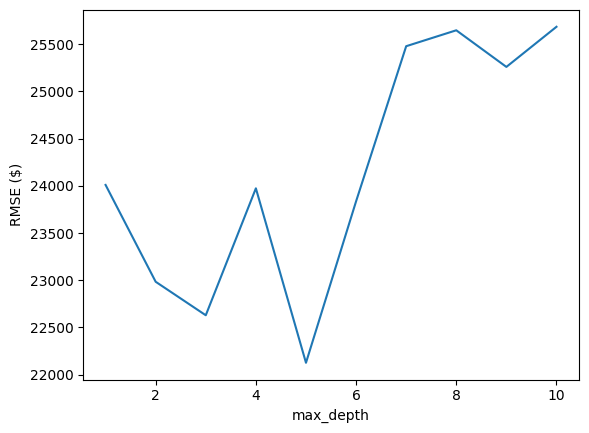

In [26]:
print(r2_list)
print(rmse_list)

plt.plot(depths, rmse_list)
plt.ylabel("RMSE ($)")
plt.xlabel("max_depth")
plt.show()
# print(f"Root Mean Squared Error: {rmse:.2f}")
# print(f"R-squared: {r2:.2f}")

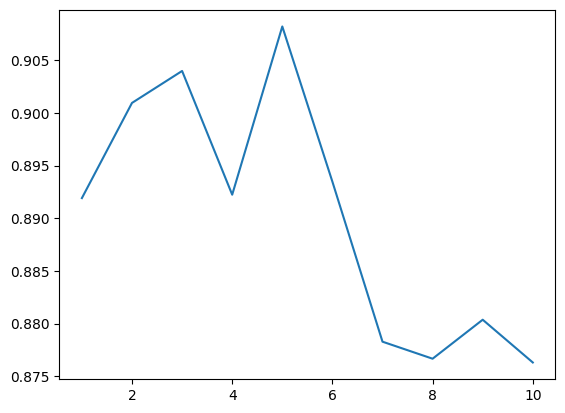

In [27]:
plt.plot(depths, r2_list)
plt.show()

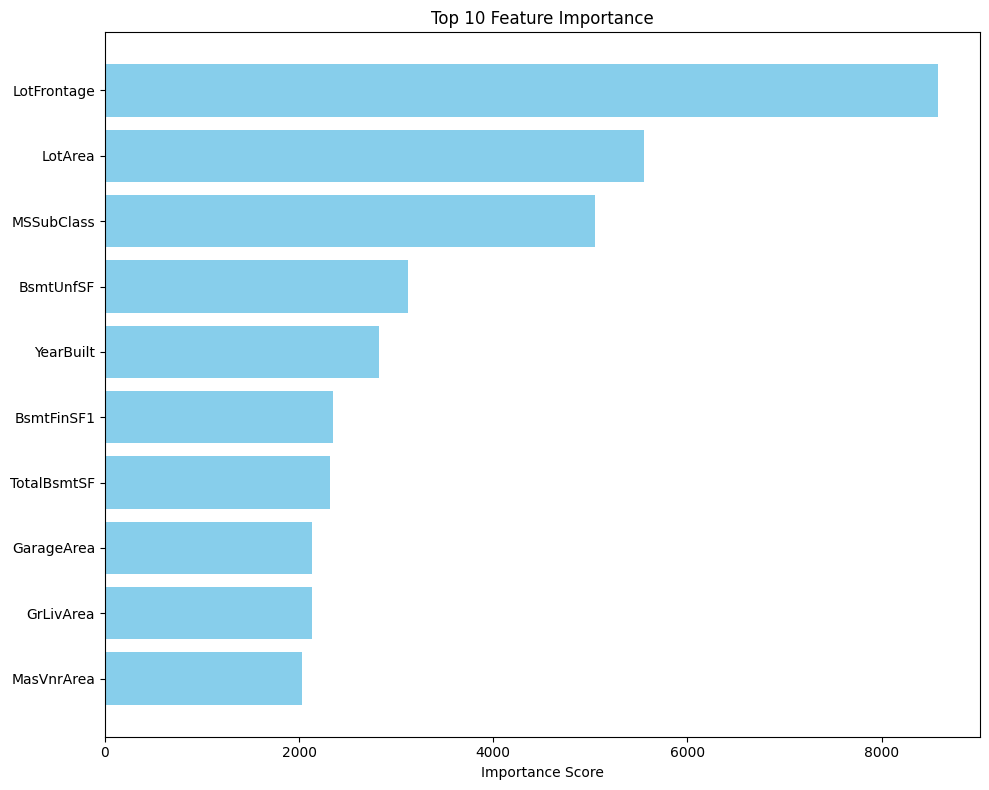

In [28]:
importance = model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 10
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

### Export best performing model predictions to kaggle

In [31]:
X_test = test_noNAN

BEST_MAX_DEPTH = 5

params['max_depth'] = BEST_MAX_DEPTH

# Train Model
model = xgb.XGBRegressor(**params)
model.fit(X_train, y_train)

# Make predictions on the validation set
y_test_pred = model.predict(X_test)

In [30]:
y_test_pred

array([140362.88, 161757.33, 184591.61, ..., 158953.3 , 115056.57,
       216372.5 ], shape=(1459,), dtype=float32)